모듈 생성

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import random
import numpy as np

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
matplotlib.rcParams['axes.unicode_minus'] = False


전처리 선언하기

In [2]:
# CIFAR-100 전처리 (학습용: 증강 포함)
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),           # 좌우 반전 (데이터 증강)
    transforms.RandomCrop(32, padding=4),        # 랜덤 크롭
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
   transforms.Normalize((0.5071, 0.4867, 0.4408), # CIFAR-100 RGB 평균
                         (0.2675, 0.2565, 0.2761))
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408),
                         (0.2675, 0.2565, 0.2761))
])

데이터셋 불러오기

In [3]:
train_dataset = datasets.CIFAR100('./data', train=True,  download=True, transform=train_transform)
test_dataset  = datasets.CIFAR100('./data', train=False, download=True, transform=test_transform)

data Loder 준비하기

In [4]:
num_workers = 2
pin_memory = torch.cuda.is_available()

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=(num_workers > 0)
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=(num_workers > 0)
)

클래스 분류 정의하기

In [5]:
classes = train_dataset.classes # CIFAR-100의 100개 클래스 이름 자동 할당

print(f"학습 데이터: {len(train_dataset)}장")
print(f"테스트 데이터: {len(test_dataset)}장")
print(f"클래스 개수: {len(classes)}개")

학습 데이터: 50000장
테스트 데이터: 10000장
클래스 개수: 100개


모델 설계

In [6]:
class CIFAR_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        # 합성곱 블록 1: 3채널 → 32채널
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)   # 32×32 → 16×16
        )
        # 합성곱 블록 2: 32채널 → 64채널
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)   # 16×16 → 8×8
        )
        # 합성곱 블록 3: 64채널 → 128채널
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)   # 8×8 → 4×4
        )
        # 완전연결층
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 100)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CIFAR_CNN().to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"파라미터 수: {total_params:,}")

파라미터 수: 1,194,084


학습 실행

In [7]:
def predict_with_tta(model, images):
    outputs_original = model(images)
    outputs_flipped = model(torch.flip(images, dims=[3]))
    return (outputs_original + outputs_flipped) / 2.0

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        predicted = outputs.argmax(dim=1)
        correct += predicted.eq(labels).sum().item()

    return total_loss / len(loader.dataset), correct / len(loader.dataset) * 100

def evaluate(model, loader, criterion, device, use_tta=True):
    model.eval()
    total_loss = 0.0
    correct = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            if use_tta:
                outputs = predict_with_tta(model, images)
            else:
                outputs = model(images)

            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            predicted = outputs.argmax(dim=1)
            correct += predicted.eq(labels).sum().item()

    return total_loss / len(loader.dataset), correct / len(loader.dataset) * 100

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 50
best_acc = 0.0
save_path = 'best_cifar100_model.pth'
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device, use_tta=True)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)

    print(
        f"Epoch {epoch:2d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} Acc: {train_acc:.1f}% | "
        f"Test Loss: {test_loss:.4f} Acc: {test_acc:.1f}%"
    )

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), save_path)

best_epoch = int(np.argmax(history['test_acc'])) + 1

model.load_state_dict(torch.load(save_path, map_location=device))
model.to(device)
model.eval()

final_test_loss, final_test_acc = evaluate(model, test_loader, criterion, device, use_tta=True)

print(f"\n최고 테스트 정확도: {best_acc:.2f}%")
print(f"최고 성능 epoch: {best_epoch}")
print(f"Best model final test acc (TTA): {final_test_acc:.2f}%")


Epoch  1/50 | Train Loss: 4.0414 Acc: 7.7% | Test Loss: 3.5088 Acc: 16.4%
Epoch  2/50 | Train Loss: 3.6173 Acc: 13.5% | Test Loss: 3.1398 Acc: 22.9%
Epoch  3/50 | Train Loss: 3.4316 Acc: 16.3% | Test Loss: 3.0501 Acc: 24.9%
Epoch  4/50 | Train Loss: 3.3068 Acc: 18.7% | Test Loss: 2.8020 Acc: 29.0%
Epoch  5/50 | Train Loss: 3.2035 Acc: 20.7% | Test Loss: 2.7326 Acc: 30.4%
Epoch  6/50 | Train Loss: 3.1373 Acc: 21.9% | Test Loss: 2.6408 Acc: 32.7%
Epoch  7/50 | Train Loss: 3.0495 Acc: 23.7% | Test Loss: 2.4932 Acc: 35.0%
Epoch  8/50 | Train Loss: 2.9904 Acc: 24.9% | Test Loss: 2.4647 Acc: 35.8%
Epoch  9/50 | Train Loss: 2.9476 Acc: 25.2% | Test Loss: 2.4151 Acc: 37.0%
Epoch 10/50 | Train Loss: 2.8991 Acc: 26.3% | Test Loss: 2.3617 Acc: 38.1%
Epoch 11/50 | Train Loss: 2.8556 Acc: 27.2% | Test Loss: 2.3417 Acc: 38.8%
Epoch 12/50 | Train Loss: 2.8200 Acc: 28.2% | Test Loss: 2.2662 Acc: 40.7%
Epoch 13/50 | Train Loss: 2.7942 Acc: 28.8% | Test Loss: 2.2812 Acc: 39.5%
Epoch 14/50 | Train Loss: 

특징 맵 시각화

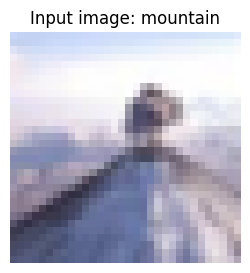

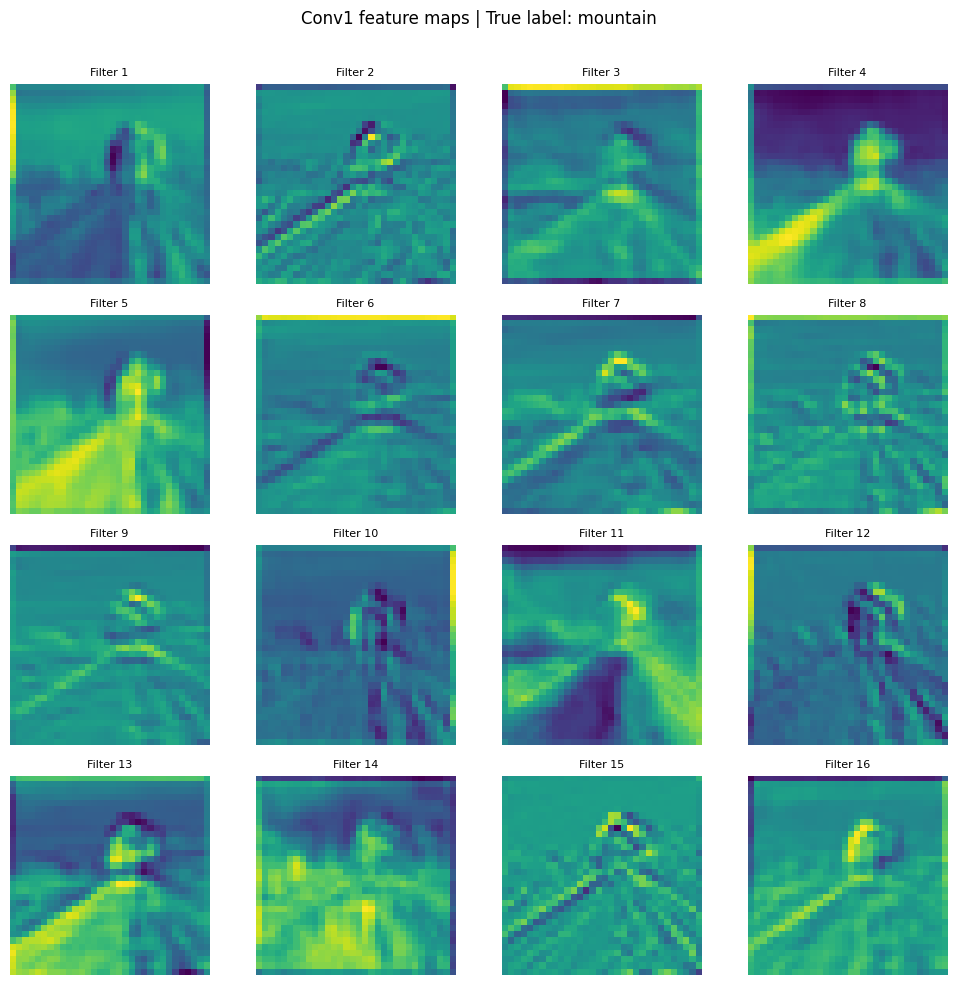

In [8]:
mean = torch.tensor([0.5071, 0.4867, 0.4408]).view(3, 1, 1)
std = torch.tensor([0.2675, 0.2565, 0.2761]).view(3, 1, 1)

def denorm(img):
    return (img * std + mean).clamp(0, 1)

image, label = test_dataset[0]
image_tensor = image.unsqueeze(0).to(device)

feature_maps = {}

def hook_fn(module, input, output):
    feature_maps['conv1'] = output.detach().cpu()

hook = model.block1[0].register_forward_hook(hook_fn)

model.eval()
with torch.no_grad():
    _ = model(image_tensor)

hook.remove()

plt.figure(figsize=(3, 3))
plt.imshow(denorm(image).permute(1, 2, 0).numpy())
plt.title(f"Input image: {classes[label]}")
plt.axis('off')
plt.show()

fmaps = feature_maps['conv1'][0]

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(fmaps[i].numpy(), cmap='viridis')
    ax.set_title(f"Filter {i+1}", fontsize=8)
    ax.axis('off')

plt.suptitle(f"Conv1 feature maps | True label: {classes[label]}", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


클래스별 예측 확인

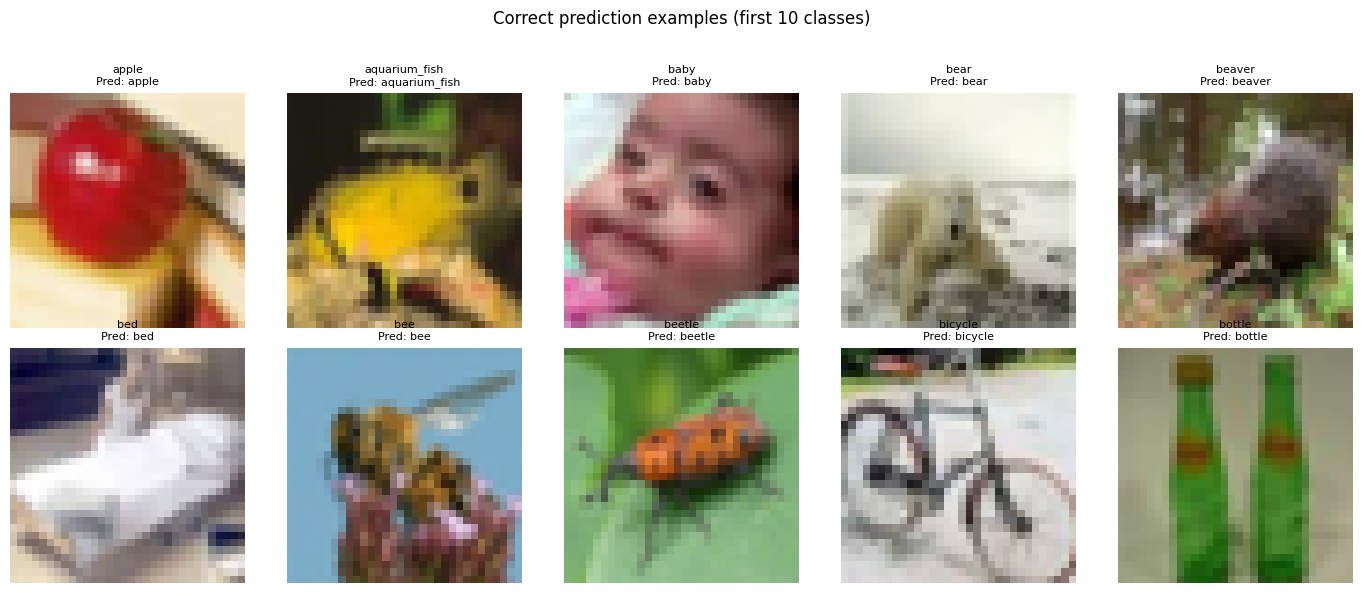

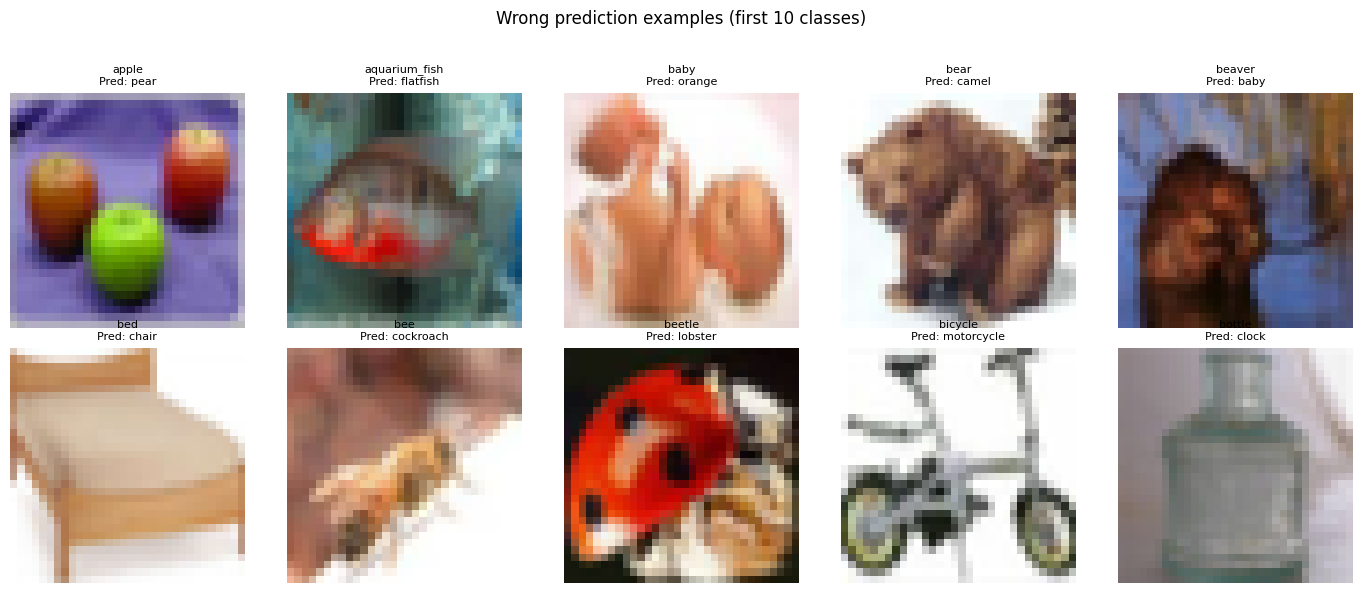

In [9]:
mean = torch.tensor([0.5071, 0.4867, 0.4408]).view(3, 1, 1)
std = torch.tensor([0.2675, 0.2565, 0.2761]).view(3, 1, 1)

def denorm(img):
    return (img * std + mean).clamp(0, 1)

model.eval()
class_correct = {c: [] for c in classes}
class_wrong = {c: [] for c in classes}

with torch.no_grad():
    for images, labels in test_loader:
        images_cpu = images
        labels_cpu = labels
        outputs = predict_with_tta(model, images.to(device, non_blocking=True))
        preds = outputs.argmax(dim=1).cpu()

        for img, true, pred in zip(images_cpu, labels_cpu, preds):
            cls = classes[true.item()]
            if true.item() == pred.item() and len(class_correct[cls]) < 1:
                class_correct[cls].append((img.clone(), pred.item()))
            elif true.item() != pred.item() and len(class_wrong[cls]) < 1:
                class_wrong[cls].append((img.clone(), pred.item()))

selected_classes = classes[:10]

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, cls in zip(axes.flat, selected_classes):
    if class_correct[cls]:
        img, pred = class_correct[cls][0]
        ax.imshow(denorm(img).permute(1, 2, 0).numpy())
        ax.set_title(f"{cls}\nPred: {classes[pred]}", fontsize=8)
    else:
        ax.set_title(f"{cls}\nNo correct sample", fontsize=8)
    ax.axis('off')

plt.suptitle("Correct prediction examples (first 10 classes)", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, cls in zip(axes.flat, selected_classes):
    if class_wrong[cls]:
        img, pred = class_wrong[cls][0]
        ax.imshow(denorm(img).permute(1, 2, 0).numpy())
        ax.set_title(f"{cls}\nPred: {classes[pred]}", fontsize=8)
    else:
        ax.set_title(f"{cls}\nNo wrong sample", fontsize=8)
    ax.axis('off')

plt.suptitle("Wrong prediction examples (first 10 classes)", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


혼동 행렬로 오류 분석

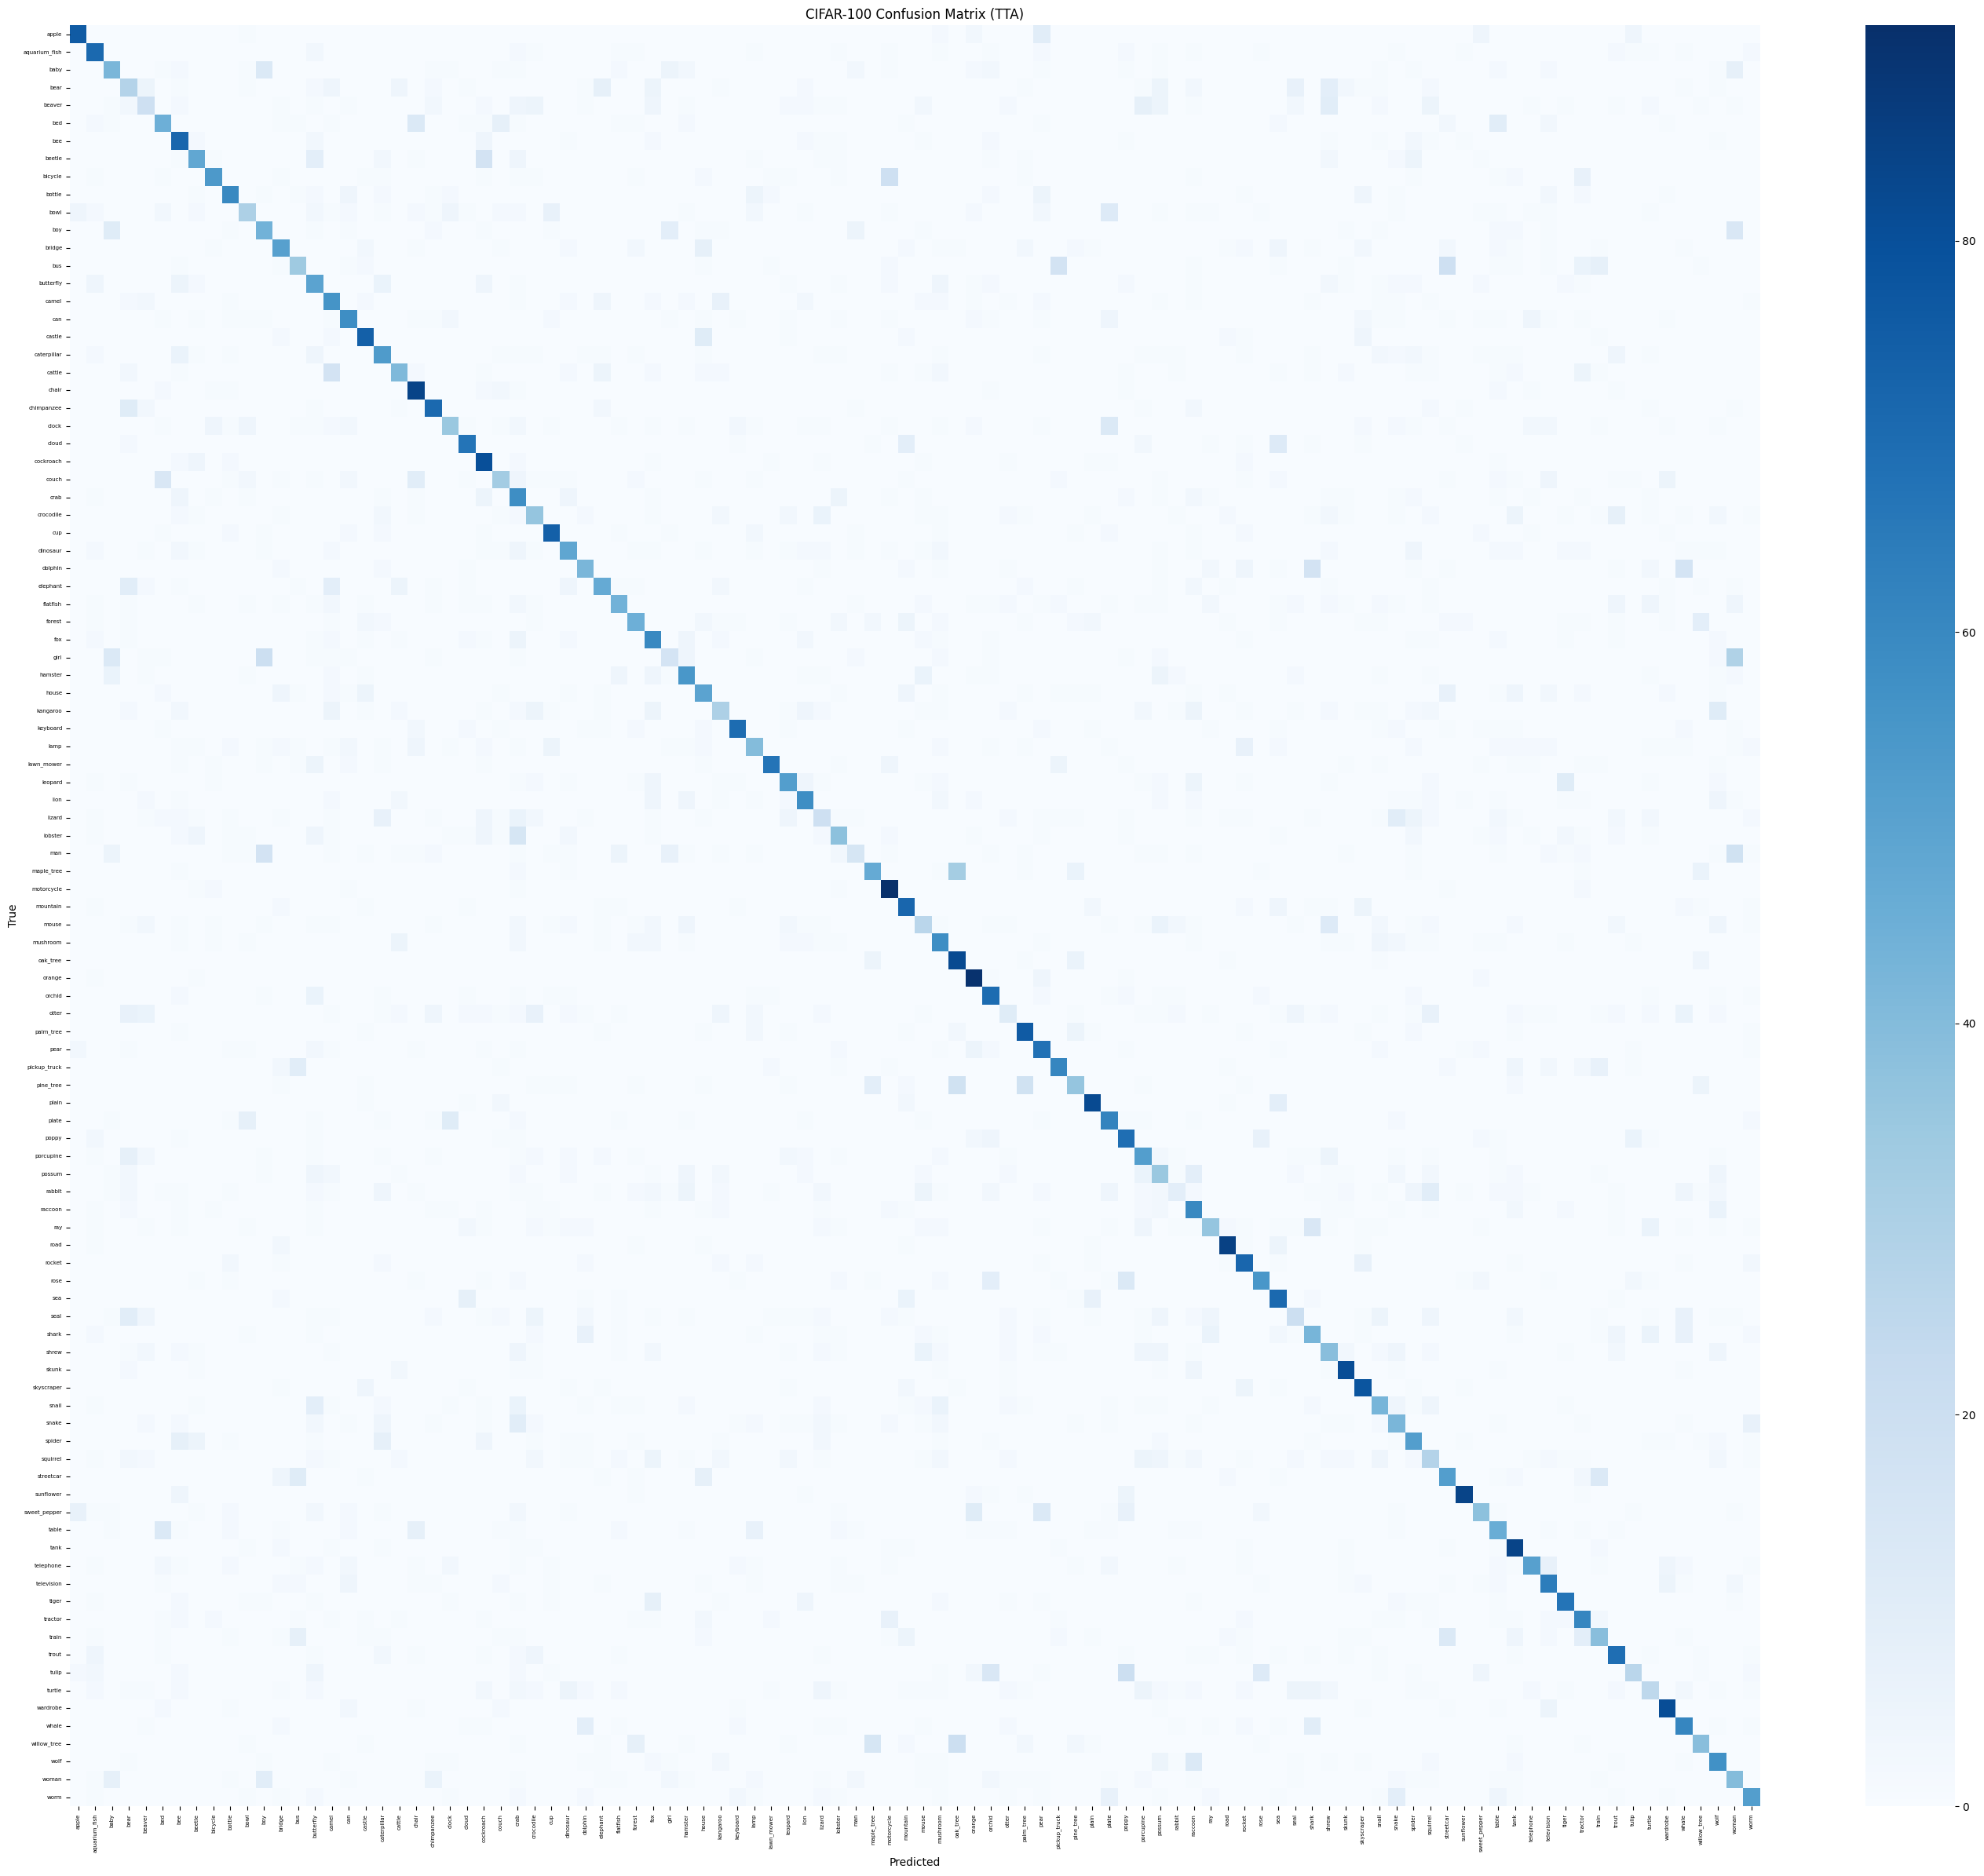

In [10]:
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = predict_with_tta(model, images.to(device, non_blocking=True))
        preds = outputs.argmax(dim=1).cpu()

        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(28, 24))
sns.heatmap(
    cm,
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('CIFAR-100 Confusion Matrix (TTA)')
plt.xticks(rotation=90, fontsize=5)
plt.yticks(rotation=0, fontsize=5)
plt.tight_layout()
plt.show()


학습 곡선 시각화

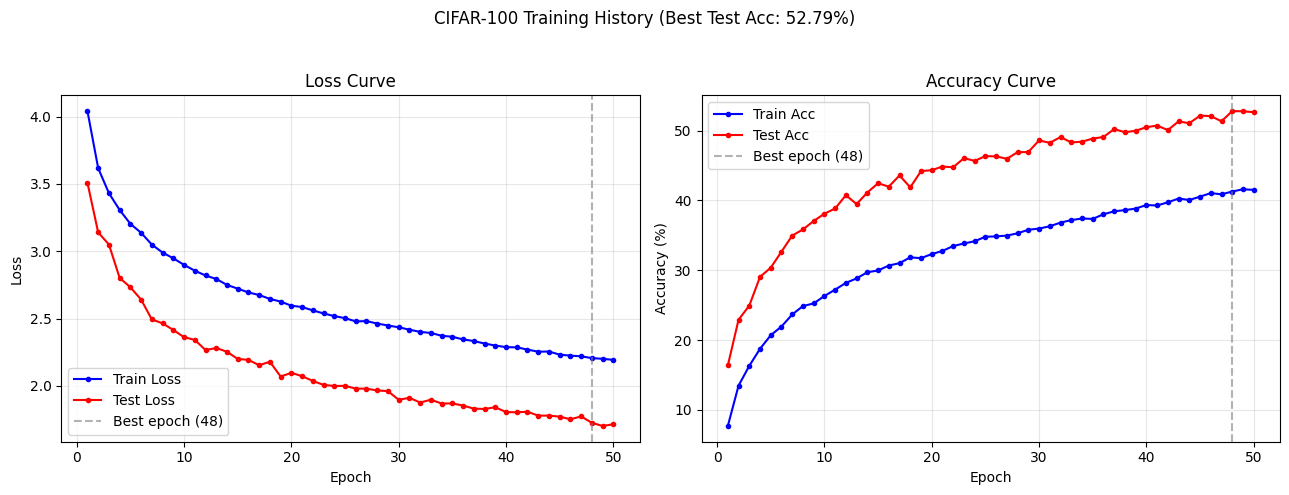

저장 완료: learning_curves.png


In [11]:
epochs_range = range(1, len(history['train_loss']) + 1)
best_epoch = int(np.argmax(history['test_acc'])) + 1

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss', markersize=3, linewidth=1.5)
axes[0].plot(epochs_range, history['test_loss'], 'r-o', label='Test Loss', markersize=3, linewidth=1.5)
axes[0].axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.6, label=f'Best epoch ({best_epoch})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curve')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history['train_acc'], 'b-o', label='Train Acc', markersize=3, linewidth=1.5)
axes[1].plot(epochs_range, history['test_acc'], 'r-o', label='Test Acc', markersize=3, linewidth=1.5)
axes[1].axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.6, label=f'Best epoch ({best_epoch})')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'CIFAR-100 Training History (Best Test Acc: {max(history["test_acc"]):.2f}%)', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("저장 완료: learning_curves.png")
